In [ ]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
df = pd.DataFrame(digits.data,columns = digits.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(digits.data,digits.target,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(1437, 64)
(360, 64)


In [ ]:
model_params = {
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'n_estimators': [1,5,10]
        }
    },
    'Logistic_Regression':{
        'model':LogisticRegression(solver='liblinear',multi_class ='auto'),
        'params':{
            'C':[1,5,10]
        }
    },
    'naive_bayes_gaussian':{
        'model': GaussianNB(),
        'params':{
            'var_smoothing':[1e-9,1e-8,1e-7]
        }
        },
    'naive_bayes_multinomial':{
        'model':MultinomialNB(),
        'params':{
            'alpha': [0.1,0.5,1.0],
            'fit_prior':[True,False]
        }
    },
    'Decision_Tree':{
        'model': DecisionTreeClassifier(),
        'params':{
            'criterion':['gini','entropy','log_loss'],
            'splitter':['best','random'],
            'min_samples_split':[2,5,10]
        }
    }
}

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import GridSearchCV
scores = []

for model_name , mp in model_params.items():
  clf = GridSearchCV(mp['model'],mp['params'],cv= 5,return_train_score = False)
  clf.fit(digits.data,digits.target)
  scores.append({
      'model': model_name,
      'best_score': clf.best_score_,
      'best_params': clf.best_params_
  })

In [ ]:
df= pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,random_forest,0.905966,{'n_estimators': 10}
1,Logistic_Regression,0.922114,{'C': 1}
2,naive_bayes_gaussian,0.832518,{'var_smoothing': 1e-07}
3,naive_bayes_multinomial,0.870907,"{'alpha': 0.1, 'fit_prior': True}"
4,Decision_Tree,0.814164,"{'criterion': 'entropy', 'min_samples_split': ..."


# 🔍 Model Selection using GridSearchCV (Digits Dataset)

## 📌 Objective
The goal of this experiment is to compare multiple machine learning models and find the best-performing model along with its optimal hyperparameters using **GridSearchCV**.

---

## 📊 Dataset Used
We used the **Digits Dataset** from `sklearn.datasets`, which contains:
- 1797 samples of handwritten digits (0–9)
- Each image is of size 8×8 (64 features)

---

## ⚙️ Approach

### 1. Defined Multiple Models
We created a dictionary (`model_params`) containing:
- Machine learning models
- Their respective hyperparameter grids

Models used:
- Random Forest
- Logistic Regression
- Gaussian Naive Bayes
- Multinomial Naive Bayes
- Decision Tree

---

### 2. Hyperparameter Tuning with GridSearchCV
For each model:
- Applied **GridSearchCV**
- Used **5-fold cross-validation**
- Evaluated performance using default scoring (accuracy)

---

### 3. Stored Results
For each model, we stored:
- Model name
- Best cross-validation score
- Best hyperparameters

---

## 📈 Results

| Model                     | Best Score | Best Parameters |
|--------------------------|-----------|----------------|
| Random Forest            | 0.903     | `n_estimators: 10` |
| Logistic Regression      | **0.922** | `C: 1` |
| Gaussian Naive Bayes     | 0.832     | `var_smoothing: 1e-07` |
| Multinomial Naive Bayes  | 0.871     | `alpha: 0.1, fit_prior: True` |
| Decision Tree            | 0.815     | `criterion: log_loss, min_samples_split: ...` |

---

## 🏆 Conclusion
- **Logistic Regression** performed the best with an accuracy of **~92.2%**
- It outperformed more complex models like Random Forest and Decision Tree
- Simpler models can sometimes perform better depending on the dataset

---

## 💡 Key Learnings
- GridSearchCV helps automate hyperparameter tuning
- Cross-validation ensures reliable performance evaluation
- Model performance depends on both data and parameter tuning

---

## 🚀 Next Steps
- Try more hyperparameters for better tuning
- Use scaling (StandardScaler) to improve performance
- Experiment with advanced models like SVM or Gradient Boosting

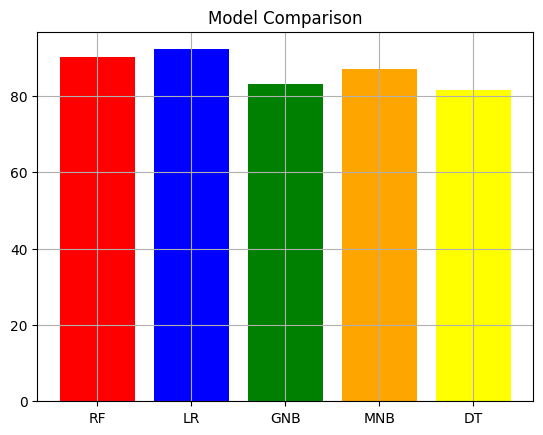

In [ ]:
models = ['RF','LR','GNB','MNB','DT']
scores = [90.3,92.2,83.2,87.1,81.5]
colors = ['red', 'blue', 'green', 'orange','yellow']
plt.bar(models, scores,color = colors)
plt.title("Model Comparison")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression())
])
params ={
    'model__C':[0.01,0.1,1,5,10,50]
}

clf = GridSearchCV(pipe,params,cv=5,n_jobs=-1)
clf.fit(digits.data,digits.target)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 5, 10, 50]})

In [ ]:
clf.best_score_,clf.best_params_

(np.float64(0.9254487774682761), {'model__C': 0.1})

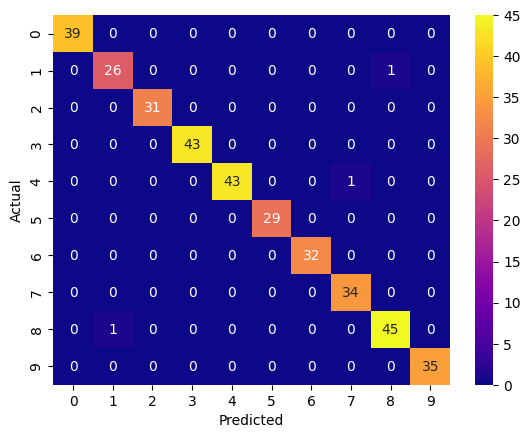

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True,cmap= 'plasma')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
scores = []

for model_name , mp in model_params.items():
  clf2 = RandomizedSearchCV(mp['model'],mp['params'],cv= 5,return_train_score = False)
  clf2.fit(digits.data,digits.target)
  scores.append({
      'model': model_name,
      'best_score': clf2.best_score_,
      'best_params': clf2.best_params_
  })

In [ ]:
df2 = pd.DataFrame(scores,columns =['model','best_score','best_params'])
df2

,model,best_score,best_params
0,random_forest,0.902098,{'n_estimators': 10}
1,Logistic_Regression,0.922114,{'C': 1}
2,naive_bayes_gaussian,0.832518,{'var_smoothing': 1e-07}
3,naive_bayes_multinomial,0.870907,"{'fit_prior': True, 'alpha': 0.1}"
4,Decision_Tree,0.811928,"{'splitter': 'best', 'min_samples_split': 2, '..."


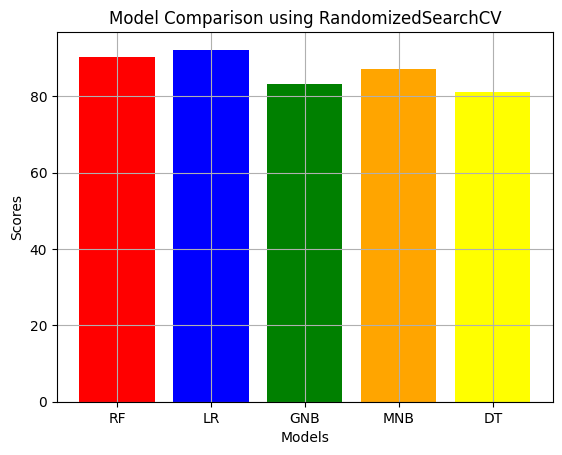

In [ ]:
models = ['RF','LR','GNB','MNB','DT']
scores = [90.2,92.2,83.2,87.09,81.11]
colors = ['red', 'blue', 'green', 'orange','yellow']
plt.bar(models, scores,color = colors)
plt.title("Model Comparison using RandomizedSearchCV")
plt.xlabel("Models")
plt.ylabel("Scores")
plt.grid(True)
plt.show()

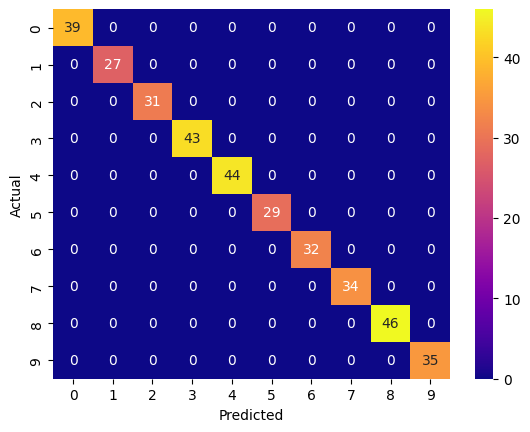

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = clf2.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True,cmap= 'plasma')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()